In [245]:
import pandas as pd
import numpy as np
import sys,os
sys.path.append("../")
from utils.utils import *
import matplotlib.pyplot as plt
import seaborn as sns
from src.fbsc import plot_signal_drift
from joblib import Parallel,delayed
from tqdm.notebook import tqdm 
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV,LeaveOneOut
import warnings

# Why should this be done before BH correction? 

- QC Samples are not used to correct for batch effects in the broadhurst method directly
- Grand Mean adjustments take into consideration all samples, QC samples are not different.  
- Instead QC samples are used to identify and remove technical variation from all other samples since, all variation in QC samples is technical. If technical variation identified from QC samples is not first corrected those technical artifacts will propagate. 

In [246]:
D = pd.read_csv("../data/2-first-13-AOU.csv").set_index('name').drop(columns=['position','height','mz'])
D = D.loc[:,D.columns.str.contains(".mzML area")]
D.columns = D.columns.str.replace(".mzML area","")
D = D.replace(0,np.nan)
min_val = D.min().min() * .10
D = D.T
M = pd.read_csv("../data/sample_metadata_all_batches_processed_samples.csv")
M = M.set_index("sample_name")
M['batch'] = M['batch'].str.split("_",expand=True)[1].astype(int)
M = M[M['batch'] <= 13]
D = D.loc[M.index]

In [247]:
M = M.sort_values(by=['batch','injection_order'])
M['injection_order'] = [x for x in range(len(M.injection_order))]

In [248]:
M[M['sample_type'] == 'sp']['batch'].value_counts()

batch
1     9
2     9
3     9
4     9
5     9
6     9
7     9
8     9
9     9
10    9
11    9
12    9
13    9
Name: count, dtype: int64

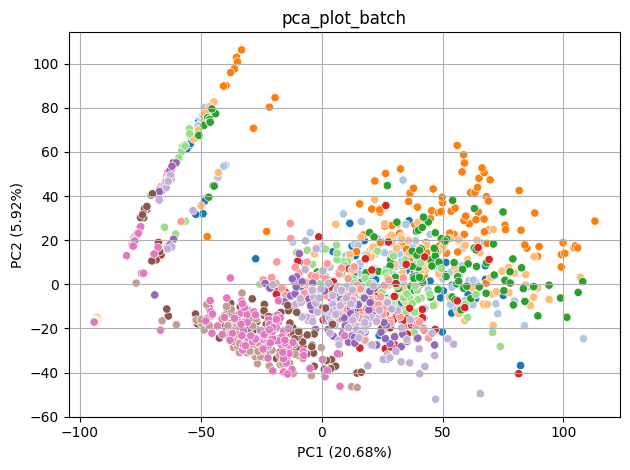

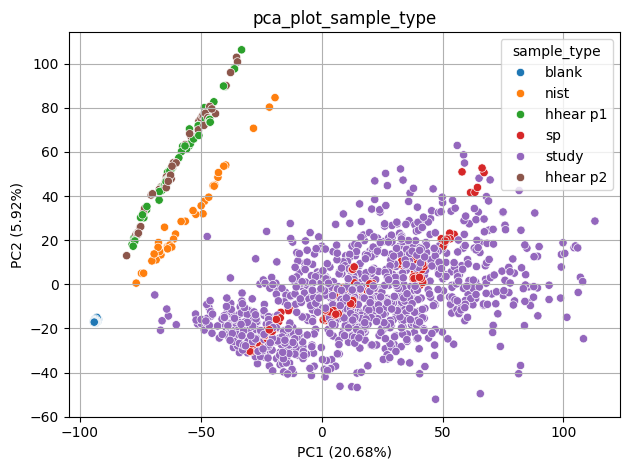

,PC1,PC2,batch,sample_type
sample_name,,,,
AOU_B_001,-92.973761,-16.422909,1,blank
AOU_NIST_001,-48.452377,37.630410,1,nist
AOU_HHEAR_P1_001,-54.763498,62.803742,1,hhear p1
AOU_SP_001,40.741898,12.881714,1,sp
AOU_S_0001,36.264525,8.377613,1,study
...,...,...,...,...
AOU_S_01040,-17.885944,-7.504134,13,study
AOU_B_0117,-94.053313,-17.148700,13,blank
AOU_NIST_039,-73.615797,5.023975,13,nist


In [249]:
pca_plot(D.fillna(min_val),M,hues=['batch','sample_type'],plot_without_blanks=False)

# RSD Distribution of QC Samples 

In [313]:
def RSD(D):
    if D.shape[0] > D.shape[1]:
        raise warnings.warn('Is Data of shape (n_samples,n_signals)?')
    value = (D.std(axis=0) / D.mean(axis=0)) * 100
    print(f'Median RSD: {value.median()}')
    return value
#Find best way to represent data distribution in the case of extensive outliers. 
def rsd_distribution(D,M,batch=None):
    QC = D[D.index.str.contains("_SP_")]
    Bio = D[~D.index.str.contains("_SP_")]
    if isinstance(batch,int):
        plt.title(f"RSD Distribution of QC Features in batch {batch}")
        batch_QC = QC.groupby(M['batch']).get_group(batch)
        sns.histplot(RSD(batch_QC))
    elif isinstance(batch,list):
        batch_QC = QC.groupby(M['batch'])
        plt.title(f"RSD Distribution of QC Features per batch")
        for i in batch:
            batch_ = batch_QC.get_group(i)
            sns.histplot(RSD(batch_),label=i,legend=True)
            plt.legend()
    else:
        plt.title("RSD Distribution of QC Features across batches")
        sns.histplot(RSD(QC))



Median RSD: 16.353082163049685
Median RSD: 17.06866419779716
Median RSD: 17.019470561955735
Median RSD: 17.293737514177867
Median RSD: 15.823161990987323
Median RSD: 16.566406978325638
Median RSD: 17.058131537672935
Median RSD: 18.204656028610547
Median RSD: 19.31819693262895
Median RSD: 17.61404888467826
Median RSD: 20.027114010948154
Median RSD: 18.524132063320867
Median RSD: 17.839161338040277


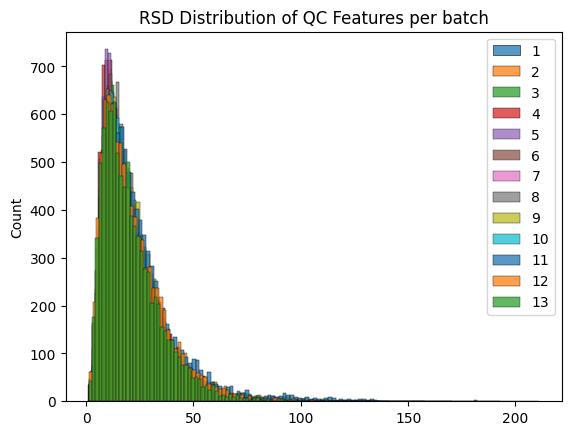

In [314]:
rsd_distribution(D,M,batch=[x for x in M['batch'].unique()])

# Plot QC Signal Against Injection Order

In [252]:
batches_3 = D.loc[M[M['batch'] <= 14].index,:]

plotting only QC and Biological Samples
plotting only QC and Biological Samples


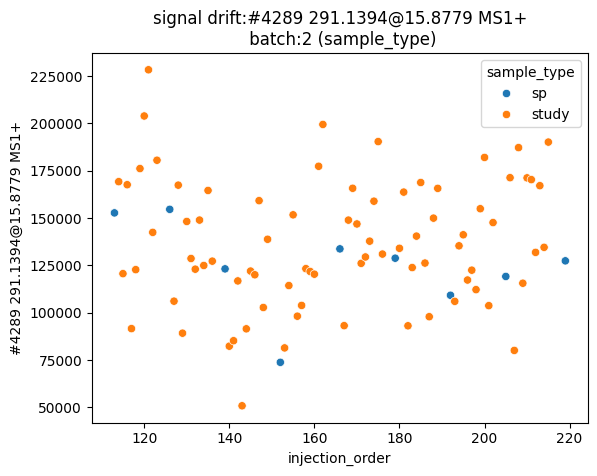

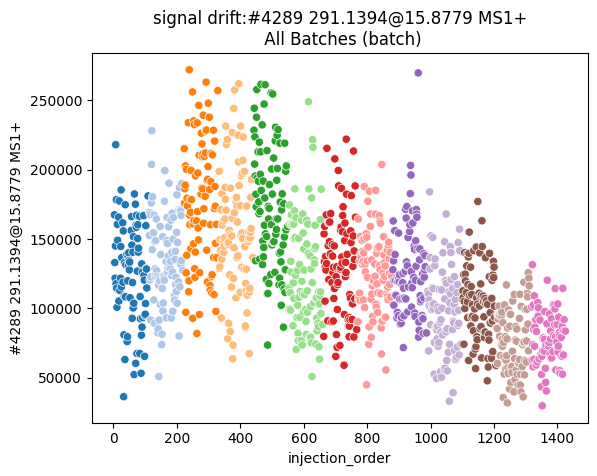

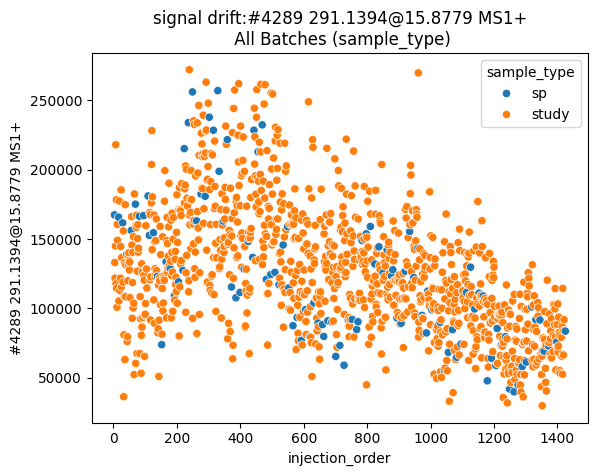

In [253]:
num = np.random.randint(high=10781,low=0)
plot_signal_drift(data=batches_3,metadata=M,include_all_samples=False,include_all_batches=False,batch_idx=2,signal_idx=4288)
plt.figure()
plot_signal_drift(data=batches_3,metadata=M,include_all_samples=False,include_all_batches=True,signal_idx=4288)


# Within Batch Effect Correction: QC-SVRC
* RBF function 
* QC signal intensity ~ injection_order (QC signal intensity as a function of injection order)

In [254]:
#specify if data is in log2, or not, if so apply correction in log space (divide values and scale by qc_intensity median)
def svr_function(qc_intensity,bio_intensity,qc_injection_order,bio_injection_order,qc1):
    params = {'kernel':['rbf'],
              'C':[C_param(qc_intensity)],
              'epsilon':[epsilon_param(qc_intensity=qc_intensity,qc1=qc1,pct_precision=15)],
              'gamma':np.logspace(-3,6,base=2)}
    if qc_intensity.isna().sum() > 5:
        return pd.concat([qc_intensity,bio_intensity],axis=0)
    else: 
        svr = SVR()
        qc_no_outliers = remove_qc_outliers(intensity=qc_intensity)
        qc_inj_no_outliers = qc_injection_order[qc_no_outliers.index]
        if qc_no_outliers.empty:
            return pd.concat([qc_intensity,bio_intensity],axis=0)
        X = qc_inj_no_outliers.to_numpy().reshape(-1,1)
        y = qc_no_outliers.to_numpy().ravel()
        cv = GridSearchCV(svr,params,n_jobs=1,scoring='neg_root_mean_squared_error',cv=LeaveOneOut())
        cv.fit(X,y)
        model = cv.best_estimator_
        fitted_values = pd.Series(model.predict(qc_injection_order.to_numpy().reshape(-1,1)),index=qc_intensity.index,name=qc_intensity.name)
        predicted_values = pd.Series(model.predict(bio_injection_order.to_numpy().reshape(-1,1)),index=bio_intensity.index,name=bio_intensity.name)
        # Kuligowski paper subtracts but how to properly remove predictions for data underneath regression curve? 
        # Could use division but would need to scale data back to original range.
        # Answer: Re-scale data using median signal intensity in qc sample, This preserves the correction while scaling the data back to an appropriate range. 
        adjusted_qc = (qc_intensity - fitted_values) + qc_intensity.median()
        adjusted_bio = (bio_intensity - predicted_values) + qc_intensity.median()
    return pd.concat([adjusted_qc,adjusted_bio],axis=0)

def remove_qc_outliers(intensity,method='median'):
    if method == 'IQR':
        Q1 = intensity.quantile(0.25)
        Q3 = intensity.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q1 - 2.5 * IQR
        lower_bound = Q3 + 2.5 * IQR
        no_outliers = intensity[(intensity > upper_bound) & (intensity < lower_bound)]
    if method == 'median':
        lower_threshold = intensity.median() * .20
        no_outliers = intensity[intensity >= lower_threshold]
    return no_outliers
def C_param(qc_intensity,lower=.10,upper=.90):
    C = qc_intensity.quantile(upper) - qc_intensity.quantile(lower)
    return C
def epsilon_param(qc_intensity,qc1,pct_precision=15):
    precision = (pct_precision / 100)
    eps = (precision / 2 )
    eps_scale = (eps * qc_intensity[qc1])
    if bool(np.isnan(eps_scale)):
        eps_scale = qc_intensity.mean() * eps
    return eps_scale

def parallel_svr_correction(data,metadata,n_jobs=-1,qc='SP'):
    group_by_batch = data.groupby(metadata['batch'])
    lst = []
    for idx,batch in group_by_batch:
        QC = batch[batch.index.str.contains(f"{qc}")]
        qc1 = metadata.loc[QC.index, 'injection_order'].idxmin()
        Bio = batch[~batch.index.str.contains(f"{qc}")]
        qc_injection_order = metadata.loc[QC.index,'injection_order']
        bio_injection_order = metadata.loc[Bio.index,'injection_order']
        results = Parallel(n_jobs=n_jobs)(delayed(svr_function)(QC[col],Bio[col],qc_injection_order,bio_injection_order,qc1) for col in tqdm(QC.columns,desc=f'Correcting signals...'))
        #results = pd.concat(results,axis=1)
        lst.append(pd.concat(results,axis=1))
    return pd.concat(lst,axis=0)

def svr_correction(data,metadata,qc='SP'):
    group_by_batch = data.groupby(metadata['batch'])
    lst = []
    for idx,batch in group_by_batch:
        QC = batch[batch.index.str.contains(f"{qc}")]
        qc1 = metadata.loc[QC.index, 'injection_order'].idxmin()
        Bio = batch[~batch.index.str.contains(f"{qc}")]
        qc_injection_order = metadata.loc[QC.index,'injection_order']
        bio_injection_order = metadata.loc[Bio.index,'injection_order']
        for signal in tqdm(data.columns):
            results = svr_function(QC[signal],Bio[signal],qc_injection_order,bio_injection_order,qc1)
            lst.append(results)
    return pd.concat(lst,axis=0)



In [255]:
results = parallel_svr_correction(D,M)

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

...

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/10781 [00:00<?, ?it/s]

Median RSD: 6.763133877679852
Median RSD: 6.9005735733415365
Median RSD: 6.746900458553949
Median RSD: 6.848286866807455
Median RSD: 6.749639928060798
Median RSD: 6.716647025453254
Median RSD: 6.918429961657882
Median RSD: 6.780247437945092
Median RSD: 6.950604135506696
Median RSD: 6.967545128825251
Median RSD: 7.192292591408387
Median RSD: 6.92503954495517
Median RSD: 6.906078496736523


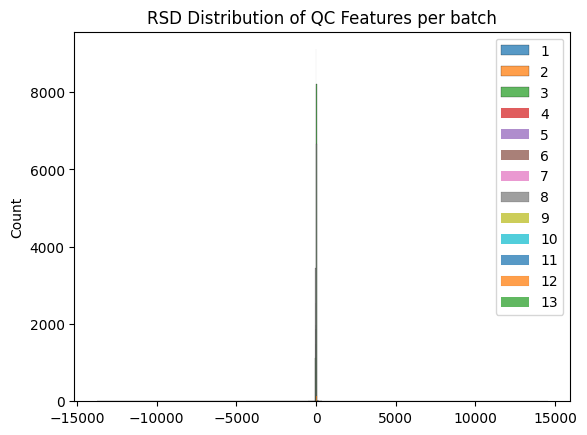

In [321]:
rsd_distribution(results,M,batch=[x for x in M.batch.unique()])

In [265]:
corrected_3 = results.loc[M[M['batch'] <= 14].index,:]

plotting only QC and Biological Samples
plotting only QC and Biological Samples


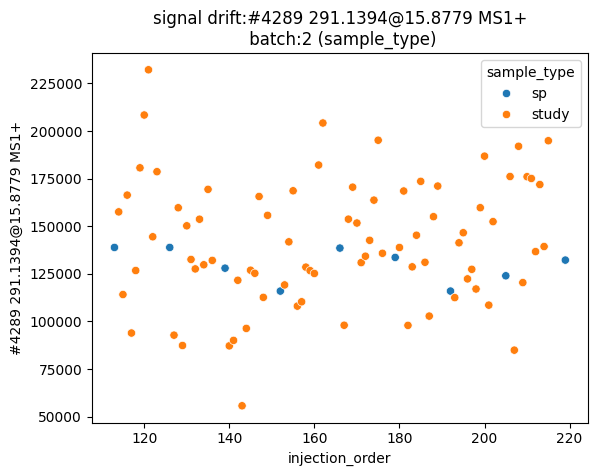

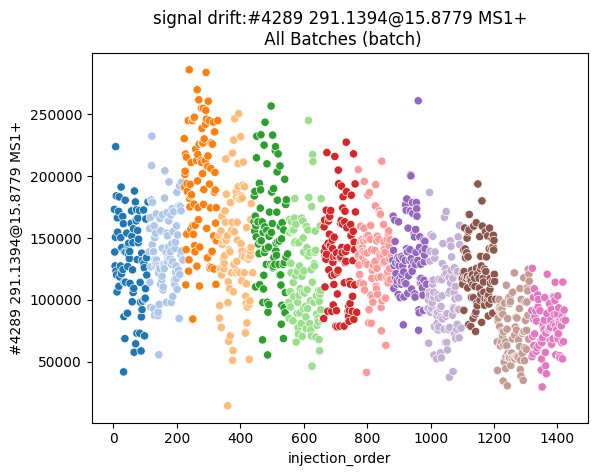

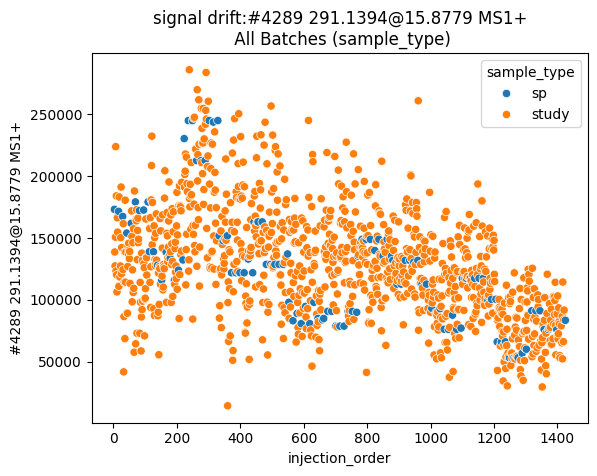

In [266]:
plot_signal_drift(data=corrected_3,metadata=M,include_all_samples=False,include_all_batches=False,signal_idx=4288,batch_idx=2)
plt.figure()
plot_signal_drift(data=corrected_3,metadata=M,include_all_samples=False,include_all_batches=True,signal_idx=4288)

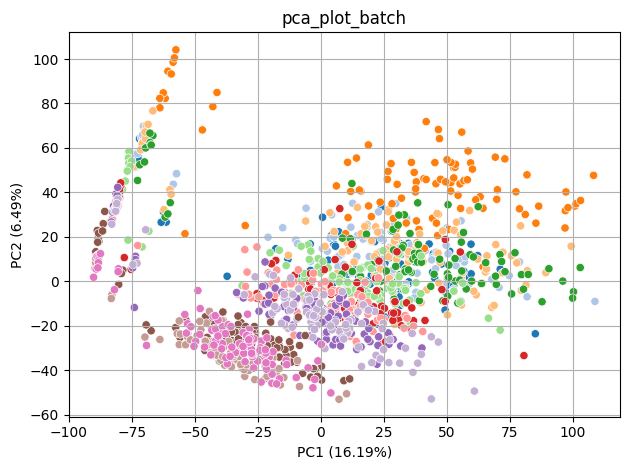

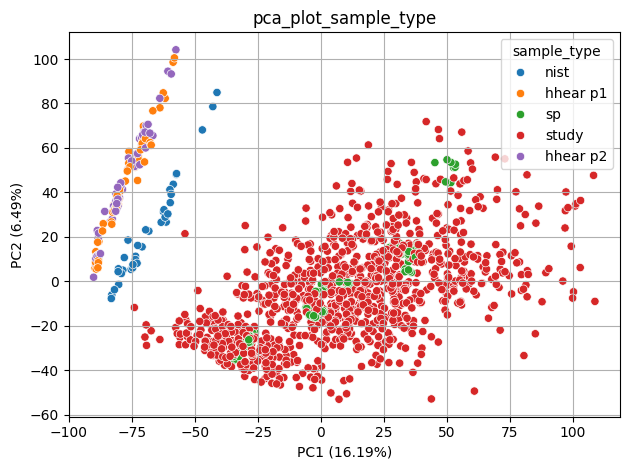

,PC1,PC2,batch,sample_type
sample_name,,,,
AOU_NIST_001,-62.343381,31.245213,1,nist
AOU_HHEAR_P1_001,-73.566105,51.440880,1,hhear p1
AOU_SP_001,31.289979,17.193141,1,sp
AOU_S_0001,27.125334,11.813505,1,study
AOU_S_0002,59.683055,16.732627,1,study
...,...,...,...,...
AOU_S_01039,-51.484015,-20.392760,13,study
AOU_S_01040,-28.986019,-14.756429,13,study
AOU_NIST_039,-81.819247,-3.760172,13,nist


In [267]:
pca_plot(corrected_3.fillna(min_val),M,hues=['batch','sample_type'],plot_without_blanks=True)

# Between Batch Effect Correction : Ratio-based Method 
- scales the intensity of each metabolic feature in each sample, using a factor defined as the ratio between the median intensity in QCs in corresponsing batch and the median intensity in QCs across batches

- group by batch and take the medians across QC samples 
- group by sample type and take the median across QC samples 

- scale each signal by this ratio 

In [ ]:
def ratio_based_correction(data,metadata,QC='sp'):
    D = data.copy()
    M = metadata.copy()
    QC = D.groupby(M['sample_type']).get_group(QC)
    median_across_qc = QC.median()
    median_qc_by_batch = []
    batches = M['batch'].unique()
    batch_group = QC.groupby(M['batch'])
    for batch in batches:
        median_qc_by_batch.append(batch_group.get_group(batch).median())
    scaling_factor = pd.concat(median_qc_by_batch,axis=1)
    scaling_factor.columns = M['batch'].unique()
    scaling_factor = scaling_factor.div(median_across_qc,axis=0)
    corrected_data = []
    batch_samples = D.groupby(M['batch'])
    for batch in batches:
        corrected_data.append(batch_samples.get_group(batch).mul(scaling_factor[batch],axis=1))
    corrected_data = pd.concat(corrected_data)
    corrected_data = corrected_data.loc[D.index]
    return corrected_data   

def BH1(D,M):
    batch_group = D.groupby(M['batch'])
    grand_mean = D[D.index.str.contains("_SP_")].mean(axis=0)
    corrected = []
    for idx,batch in batch_group:
        batch_mean = batch[batch.index.str.contains("_SP_")].mean(axis=0)
        error = batch_mean - grand_mean
        batch -= error
        corrected.append(batch)
    return pd.concat(corrected,axis=0) 
        

plotting only QC and Biological Samples


<Figure size 640x480 with 0 Axes>

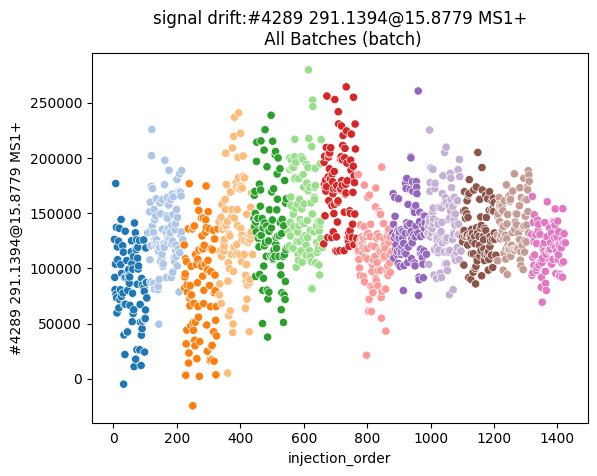

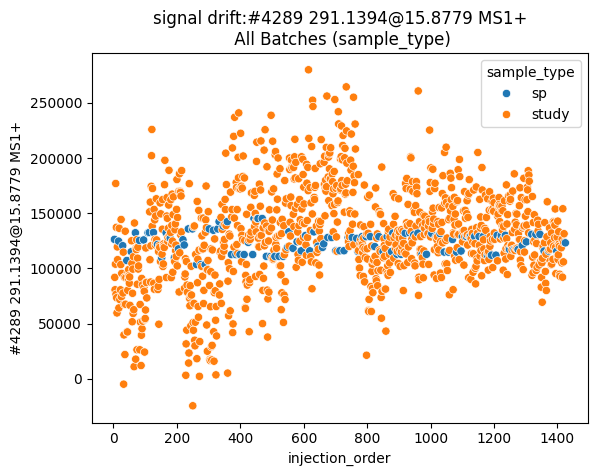

<Figure size 640x480 with 0 Axes>

In [270]:
plot_signal_drift(data=BH1(corrected_3,M),metadata=M,include_all_samples=False,include_all_batches=True,signal_idx=4288)
plt.figure()

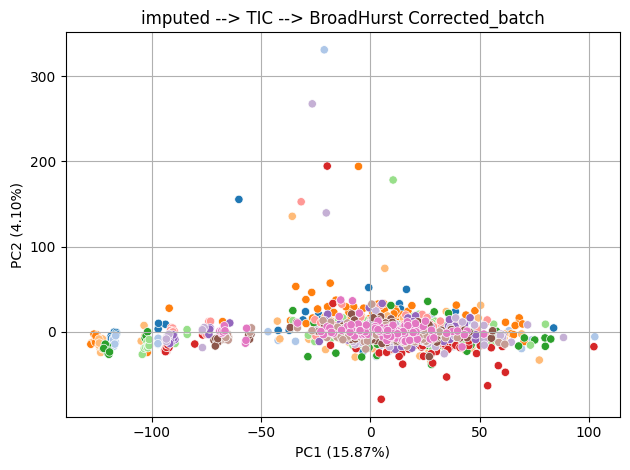

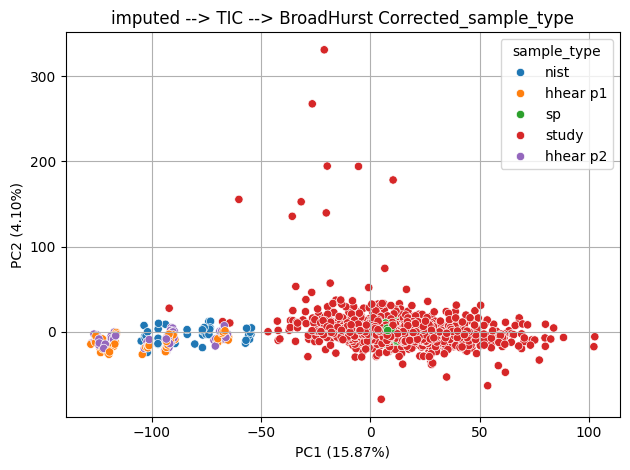

In [278]:
df = pca_plot(BH1(batches_3.fillna(min_val),M),M=M,title='imputed --> TIC --> BroadHurst Corrected',hues=['batch','sample_type'])

Median RSD: 8.153028526907296
Median RSD: 7.801558089580698
Median RSD: 8.915557630354474
Median RSD: 8.06677454807712
Median RSD: 8.175455806642795
Median RSD: 6.347256156225709
Median RSD: 5.932088434427328
Median RSD: 6.016070968214032
Median RSD: 6.085439119702276
Median RSD: 6.409826212156999
Median RSD: 5.172482106361715
Median RSD: 4.695368096358274
Median RSD: 5.071571870245949


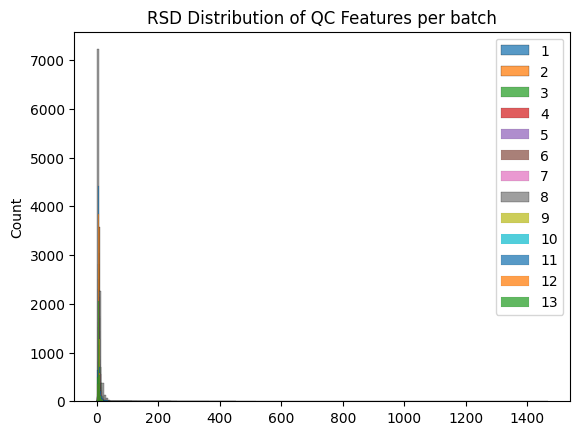

In [322]:
rsd_distribution(BH1(corrected_3,M),M,batch=[x for x in M['batch'].unique()])